In [115]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [116]:
# ── 通道定義 & 五腦區分組 ──
CH_NAMES = [
    'Fp1','Fz','F3','F7','FT9','FC5','FC1',   # 0-6
    'C3','T7','TP9','CP5','CP1','Pz','P3','P7', # 7-14
    'O1','Oz','O2',                              # 15-17
    'P4','P8','TP10','CP6','CP2','Cz','C4','T8', # 18-25
    'FT10','FC6','FC2','F4','F8','Fp2'           # 26-31
]

REGIONS = {
    'Frontal':   [0, 31, 2, 29, 3, 30, 1],
    'Central':   [7, 24, 23, 6, 28, 5, 27],
    'Parietal':  [13, 18, 14, 19, 12, 11, 22, 10, 21],
    'Temporal':  [8, 25, 4, 26, 9, 20],
    'Occipital': [15, 17, 16],
}

BAND_NAMES = ['delta', 'theta', 'alpha', 'beta', 'gamma']
CLASS_NAMES = ['amateur', 'master', 'prof']

In [117]:
# ── PLV 資料載入 ──

def get_subject_id(filename):
    return filename.split('_ses-')[0]

def scan_folder(folder_path):
    result = {}
    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.mat'):
            result[get_subject_id(fname)] = os.path.join(folder_path, fname)
    return result

def load_plv(filepath):
    with h5py.File(filepath, 'r') as f:
        rm = f['result_mats']
        bands_data = []
        for band in BAND_NAMES:
            bands_data.append(np.array(rm[band]))
    return np.array(bands_data)  # (5, 200, 32, 32)

def load_plv_group(ss01_map, ss02_map, ss03_map, complete_subs):
    X1, X2, X3 = [], [], []
    for sub_id in complete_subs:
        X1.append(load_plv(ss01_map[sub_id]))
        X2.append(load_plv(ss02_map[sub_id]))
        X3.append(load_plv(ss03_map[sub_id]))
    return np.array(X1), np.array(X2), np.array(X3)

def load_band_energy(filepath):
    with h5py.File(filepath, 'r') as f:
        data = np.array(f['band_energy']).T
    return data  # (32ch, 39time, 5bands)

def load_be_group(ss01_map, ss02_map, ss03_map, complete_subs):
    X1, X2, X3 = [], [], []
    for sub_id in complete_subs:
        X1.append(load_band_energy(ss01_map[sub_id]))
        X2.append(load_band_energy(ss02_map[sub_id]))
        X3.append(load_band_energy(ss03_map[sub_id]))
    return np.array(X1), np.array(X2), np.array(X3)

# PLV paths
BASE_PLV = {
    'amateur': r'D:\Tseng\圍棋\amateur\PLV_Results_2026',
    'master':  r'D:\Tseng\圍棋\master\PLV_Results_2026',
    'prof':    r'D:\Tseng\圍棋\prof\PLV_Results_2026',
}
# Band Energy paths
BASE_BE = {
    'amateur': r'D:\Tseng\圍棋\amateur\band_energy_batch_outputs_2026',
    'master':  r'D:\Tseng\圍棋\master\band_energy_batch_outputs_2026',
    'prof':    r'D:\Tseng\圍棋\prof\band_energy_batch_outputs_2026',
}

# 載入 PLV
plv_maps, complete = {}, {}
for group in CLASS_NAMES:
    paths = {s: os.path.join(BASE_PLV[group], s) for s in ['ss01','ss02','ss03']}
    m1, m2, m3 = scan_folder(paths['ss01']), scan_folder(paths['ss02']), scan_folder(paths['ss03'])
    plv_maps[group] = (m1, m2, m3)
    complete[group] = sorted(set(m1) & set(m2) & set(m3))
    print(f'[{group}] 完整 subject：{len(complete[group])} 人')

print('\n載入 PLV 資料...')
X_a1, X_a2, X_a3 = load_plv_group(*plv_maps['amateur'], complete['amateur'])
X_m1, X_m2, X_m3 = load_plv_group(*plv_maps['master'],  complete['master'])
X_p1, X_p2, X_p3 = load_plv_group(*plv_maps['prof'],    complete['prof'])
print(f'PLV shape: {X_a1.shape},{X_m1.shape},{X_p1.shape}')

# 載入 Band Energy
print('\n載入 Band Energy 資料...')
be_maps = {}
for group in CLASS_NAMES:
    paths = {s: os.path.join(BASE_BE[group], s) for s in ['ss01','ss02','ss03']}
    be_maps[group] = (scan_folder(paths['ss01']), scan_folder(paths['ss02']), scan_folder(paths['ss03']))

BE_a1, BE_a2, BE_a3 = load_be_group(*be_maps['amateur'], complete['amateur'])
BE_m1, BE_m2, BE_m3 = load_be_group(*be_maps['master'],  complete['master'])
BE_p1, BE_p2, BE_p3 = load_be_group(*be_maps['prof'],    complete['prof'])
print(f'BE shape:  {BE_a1.shape}')


[amateur] 完整 subject：28 人
[master] 完整 subject：20 人
[prof] 完整 subject：8 人

載入 PLV 資料...
PLV shape: (28, 5, 200, 32, 32),(20, 5, 200, 32, 32),(8, 5, 200, 32, 32)

載入 Band Energy 資料...
BE shape:  (28, 32, 39, 5)


In [118]:
# ── 特徵提取 & 標籤準備 ──

triu_idx = np.triu_indices(32, k=1)

def extract_plv_features(X, ch_idx=None):
    X_mean = X.mean(axis=2)
    if ch_idx is not None:
        X_mean = X_mean[:, :, np.ix_(ch_idx, ch_idx)[0], np.ix_(ch_idx, ch_idx)[1]]
        n_ch = len(ch_idx)
        tri = np.triu_indices(n_ch, k=1)
    else:
        tri = triu_idx
    feats = []
    for b in range(5):
        feats.append(X_mean[:, b, tri[0], tri[1]])
    return np.hstack(feats)

def extract_be_features(X_be, ch_idx=None):
    X = np.log(X_be + 1e-8)
    X = X[:, :, 1:-1, :]
    X = X.mean(axis=2)
    if ch_idx is not None:
        X = X[:, ch_idx, :]
    return X.reshape(len(X), -1)

n_a = len(complete['amateur'])
n_m = len(complete['master'])
n_p = len(complete['prof'])

# PLV: group-then-session
plv_all = []
for g in CLASS_NAMES:
    for Xr in [{'amateur': [X_a1,X_a2,X_a3], 'master': [X_m1,X_m2,X_m3], 'prof': [X_p1,X_p2,X_p3]}[g]]:
        for x in Xr:
            plv_all.append(x)
X_plv = np.vstack(plv_all)  # (168, 5, 200, 32, 32)

# BE: group-then-session
be_all = []
for g in CLASS_NAMES:
    for Xr in [{'amateur': [BE_a1,BE_a2,BE_a3], 'master': [BE_m1,BE_m2,BE_m3], 'prof': [BE_p1,BE_p2,BE_p3]}[g]]:
        for x in Xr:
            be_all.append(x)
X_be = np.vstack(be_all)  # (168, 32, 39, 5)

y_all = np.concatenate([np.zeros(n_a * 3), np.ones(n_m * 3), np.full(n_p * 3, 2)])
subject_ids = complete['amateur'] + complete['master'] + complete['prof']
subject_split = np.concatenate([
    np.repeat(complete['amateur'], 3),
    np.repeat(complete['master'], 3),
    np.repeat(complete['prof'], 3),
])
subject_labels = {}
for g_idx, g in enumerate(CLASS_NAMES):
    for s in complete[g]:
        subject_labels[s] = g_idx

print(f'X_plv: {X_plv.shape}  X_be: {X_be.shape}  y: {y_all.shape}')


X_plv: (168, 5, 200, 32, 32)  X_be: (168, 32, 39, 5)  y: (168,)


In [119]:
# ── PLV + BE 分開 PCA（95% 解釋變異）再合併 LOSO ──

def run_loso_combined(X_plv, X_be, ch_idx, y_all, subject_split, subject_ids, subject_labels,
                      pca_variance=0.95):
    feat_plv = extract_plv_features(X_plv, ch_idx)
    feat_be  = extract_be_features(X_be, ch_idx)

    dims_plv = feat_plv.shape[1]
    dims_be  = feat_be.shape[1]

    all_preds, all_true, all_proba = [], [], []
    per_sub = []
    pca_plv_dims_list = []
    pca_be_dims_list = []

    for test_subject in subject_ids:
        test_mask  = subject_split == test_subject
        train_mask = ~test_mask

        y_tr = y_all[train_mask].astype(int)
        y_te = y_all[test_mask].astype(int)

        # PLV branch: scale -> PCA(95%)
        plv_tr, plv_te = feat_plv[train_mask], feat_plv[test_mask]
        scaler_plv = StandardScaler()
        plv_tr = scaler_plv.fit_transform(plv_tr)
        plv_te = scaler_plv.transform(plv_te)
        pca_plv_obj = PCA(n_components=pca_variance)
        plv_tr = pca_plv_obj.fit_transform(plv_tr)
        plv_te = pca_plv_obj.transform(plv_te)
        pca_plv_dims_list.append(pca_plv_obj.n_components_)

        # BE branch: scale -> PCA(95%)
        be_tr, be_te = feat_be[train_mask], feat_be[test_mask]
        scaler_be = StandardScaler()
        be_tr = scaler_be.fit_transform(be_tr)
        be_te = scaler_be.transform(be_te)
        pca_be_obj = PCA(n_components=pca_variance)
        be_tr = pca_be_obj.fit_transform(be_tr)
        be_te = pca_be_obj.transform(be_te)
        pca_be_dims_list.append(pca_be_obj.n_components_)

        # 合併 PCA 後的特徵
        X_tr = np.hstack([plv_tr, be_tr])
        X_te = np.hstack([plv_te, be_te])

        # concat 後再做一次 StandardScaler：讓 PLV/BE 的每個 PC 在 SVM 距離計算中權重一致
        scaler_final = StandardScaler()
        X_tr = scaler_final.fit_transform(X_tr)
        X_te = scaler_final.transform(X_te)

        clf = SVC(kernel='rbf', C=10, gamma='scale',
                  class_weight='balanced', random_state=42,
                  probability=True)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)
        proba = clf.predict_proba(X_te)  # (3, 3) for 3 sessions

        acc = accuracy_score(y_te, preds)
        f1  = f1_score(y_te, preds, average='macro', zero_division=0)
        per_sub.append({'acc': acc, 'f1': f1, 'subject': test_subject,
                        'true': subject_labels[test_subject]})
        all_preds.extend(preds)
        all_true.extend(y_te)
        all_proba.extend(proba)

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)
    all_proba = np.array(all_proba)  # (168, 3)
    mean_acc = np.mean([r['acc'] for r in per_sub])
    mean_f1  = f1_score(all_true, all_preds, average='macro', zero_division=0)
    dims = dims_plv + dims_be
    # 取各 fold 的中位數作為代表 PCA 維度
    pca_plv_n = int(np.median(pca_plv_dims_list))
    pca_be_n  = int(np.median(pca_be_dims_list))
    pca_n = pca_plv_n + pca_be_n
    return mean_acc, mean_f1, per_sub, all_preds, all_true, all_proba, dims, pca_n, pca_plv_n, pca_be_n

# ── 五腦區 LOSO ──
combined_results = {}

for region_name, ch_idx in REGIONS.items():
    n_ch = len(ch_idx)
    acc, f1, per_sub, preds, true, proba, dims, pca_n, pca_plv_n, pca_be_n = run_loso_combined(
        X_plv, X_be, ch_idx, y_all, subject_split, subject_ids, subject_labels,
        pca_variance=0.95
    )
    n_plv = len(np.triu_indices(n_ch, k=1)[0]) * 5
    n_be  = n_ch * 5
    combined_results[region_name] = {
        'acc': acc, 'f1': f1, 'dims': dims, 'pca': pca_n,
        'preds': preds, 'true': true, 'proba': proba, 'per_sub': per_sub,
        'ch_idx': ch_idx, 'pca_plv_n': pca_plv_n, 'pca_be_n': pca_be_n,
    }
    print(f'[{region_name:<10s}] PLV={n_plv:3d}(95%→{pca_plv_n:2d}) + BE={n_be:2d}(95%→{pca_be_n:2d}) = {dims:4d} dims  '
          f'PCA total={pca_n:2d}  Acc={acc:.3f}  F1={f1:.3f}')

[Frontal   ] PLV=105(95%→16) + BE=35(95%→ 7) =  140 dims  PCA total=23  Acc=0.708  F1=0.672
[Central   ] PLV=105(95%→19) + BE=35(95%→ 8) =  140 dims  PCA total=27  Acc=0.744  F1=0.755
[Parietal  ] PLV=180(95%→21) + BE=45(95%→ 7) =  225 dims  PCA total=28  Acc=0.839  F1=0.838
[Temporal  ] PLV= 75(95%→10) + BE=30(95%→ 6) =  105 dims  PCA total=16  Acc=0.619  F1=0.584
[Occipital ] PLV= 15(95%→ 4) + BE=15(95%→ 4) =   30 dims  PCA total= 8  Acc=0.536  F1=0.530


Band Energy vs PLV vs Combined (PLV+BE) — SVM 3-Class LOSO
Region         BE Acc  PLV Acc  Comb Acc    BE F1   PLV F1   Comb F1
------------------------------------------------------------------------------------------
Frontal         0.643    0.536     0.708    0.615    0.491     0.672
Central         0.601    0.583     0.744    0.575    0.526     0.755
Parietal        0.708    0.738     0.839    0.691    0.736     0.838
Temporal        0.577    0.506     0.619    0.555    0.468     0.584
Occipital       0.500    0.446     0.536    0.492    0.444     0.530


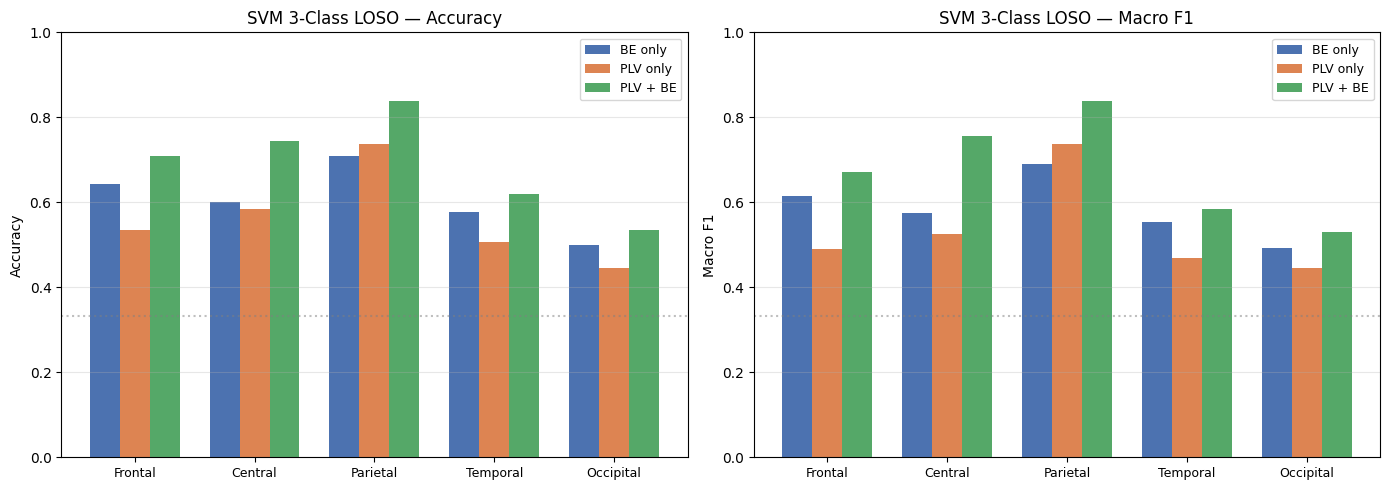

In [120]:
# ── 三方比較表：BE vs PLV vs Combined ──

import json

# 從 svm_band_energy.ipynb 與 svm_plv.ipynb 的輸出 JSON 讀回結果
# (記得先跑過那兩個 notebook 才會有檔案)
with open(r'D:\Tseng\game_eeg\SVM_BE\svm_band_energy_results.json', 'r', encoding='utf-8') as _f:
    be_results = json.load(_f)
with open(r'D:\Tseng\game_eeg\SVM_PLV\svm_plv_results.json', 'r', encoding='utf-8') as _f:
    plv_results = json.load(_f)

print('=' * 90)
print('Band Energy vs PLV vs Combined (PLV+BE) \u2014 SVM 3-Class LOSO')
print('=' * 90)
print(f'{"Region":<12s} {"BE Acc":>8s} {"PLV Acc":>8s} {"Comb Acc":>9s} '
      f'{"BE F1":>8s} {"PLV F1":>8s} {"Comb F1":>9s}')
print('-' * 90)

for rn in REGIONS:
    be  = be_results[rn]
    plv = plv_results[rn]
    cmb = combined_results[rn]
    print(f'{rn:<12s} {be["acc"]:8.3f} {plv["acc"]:8.3f} {cmb["acc"]:9.3f} '
          f'{be["f1"]:8.3f} {plv["f1"]:8.3f} {cmb["f1"]:9.3f}')
print('=' * 90)

# ── Bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
region_names = list(REGIONS.keys())
x = np.arange(len(region_names))
width = 0.25

for ax_idx, (metric, title) in enumerate([('acc', 'Accuracy'), ('f1', 'Macro F1')]):
    ax = axes[ax_idx]
    be_vals  = [be_results[rn][metric] for rn in region_names]
    plv_vals = [plv_results[rn][metric] for rn in region_names]
    cmb_vals = [combined_results[rn][metric] for rn in region_names]

    ax.bar(x - width, be_vals,  width, label='BE only',  color='#4C72B0')
    ax.bar(x,         plv_vals, width, label='PLV only', color='#DD8452')
    ax.bar(x + width, cmb_vals, width, label='PLV + BE', color='#55A868')

    ax.set_xticks(x)
    ax.set_xticklabels(region_names, fontsize=9)
    ax.set_ylabel(title)
    ax.set_title(f'SVM 3-Class LOSO \u2014 {title}')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)
    ax.axhline(y=1/3, color='gray', linestyle=':', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV_BE\svm_plv_be_combined_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()

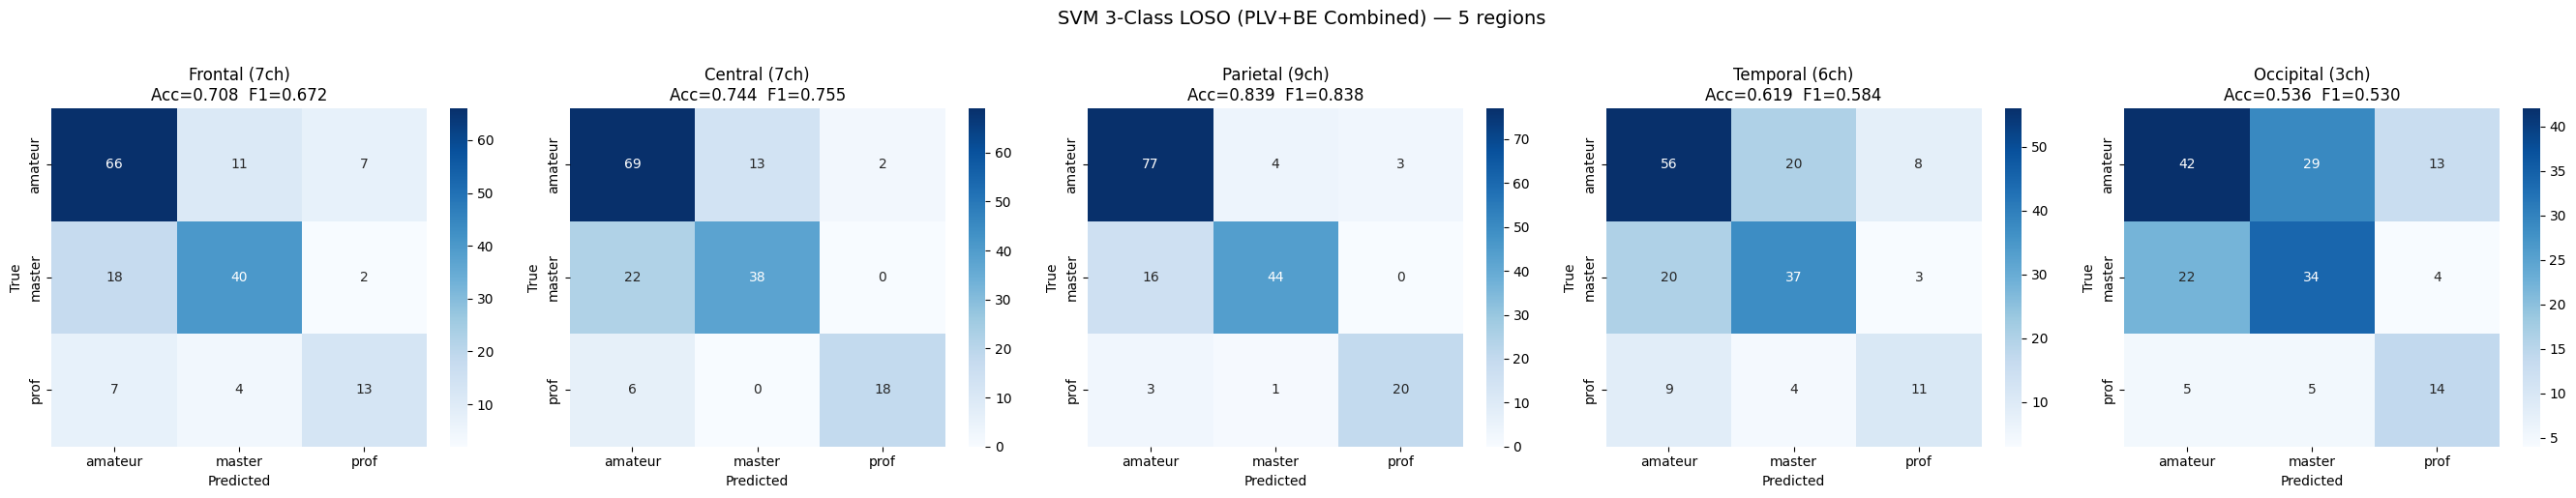

In [121]:
# ── 混淆矩陣 ──

fig, axes = plt.subplots(1, 5, figsize=(27, 5))

for ax, (region_name, r) in zip(axes, combined_results.items()):
    cm = confusion_matrix(r['true'], r['preds'], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    n_ch = len(r['ch_idx'])
    ax.set_title(f'{region_name} ({n_ch}ch)\nAcc={r["acc"]:.3f}  F1={r["f1"]:.3f}')

plt.suptitle('SVM 3-Class LOSO (PLV+BE Combined) \u2014 5 regions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV_BE\svm_plv_be_combined_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [122]:
# ── 各腦區 Classification Report ──

for region_name, r in combined_results.items():
    n_ch = len(r['ch_idx'])
    print(f'\n{"="*60}')
    print(f'{region_name} ({n_ch}ch)  Acc={r["acc"]:.3f}  F1={r["f1"]:.3f}')
    print(f'{"="*60}')
    print(classification_report(r['true'], r['preds'],
                                target_names=CLASS_NAMES, zero_division=0))


Frontal (7ch)  Acc=0.708  F1=0.672
              precision    recall  f1-score   support

     amateur       0.73      0.79      0.75        84
      master       0.73      0.67      0.70        60
        prof       0.59      0.54      0.57        24

    accuracy                           0.71       168
   macro avg       0.68      0.66      0.67       168
weighted avg       0.71      0.71      0.71       168


Central (7ch)  Acc=0.744  F1=0.755
              precision    recall  f1-score   support

     amateur       0.71      0.82      0.76        84
      master       0.75      0.63      0.68        60
        prof       0.90      0.75      0.82        24

    accuracy                           0.74       168
   macro avg       0.79      0.73      0.76       168
weighted avg       0.75      0.74      0.74       168


Parietal (9ch)  Acc=0.839  F1=0.838
              precision    recall  f1-score   support

     amateur       0.80      0.92      0.86        84
      master       0

Parietal — Hard Vote vs Soft Vote (PLV→40 + BE→20)
Subject             True    ss01    ss02    ss03    Hard    Soft      Soft Prob (am/ma/pr)   H   S
---------------------------------------------------------------------------------------------------------
sub-22           amateur amateur amateur amateur amateur amateur      [0.71 / 0.25 / 0.04]   O   O
sub-23           amateur amateur amateur amateur amateur amateur      [0.84 / 0.12 / 0.04]   O   O
sub-24           amateur  master amateur amateur amateur amateur      [0.51 / 0.44 / 0.06]   O   O
sub-33           amateur amateur amateur amateur amateur amateur      [0.72 / 0.18 / 0.10]   O   O
sub-38           amateur amateur amateur amateur amateur amateur      [0.78 / 0.19 / 0.03]   O   O
sub-39           amateur amateur amateur amateur amateur amateur      [0.82 / 0.15 / 0.03]   O   O
sub-40           amateur amateur amateur amateur amateur amateur      [0.76 / 0.18 / 0.05]   O   O
sub-41           amateur amateur amateur    prof am

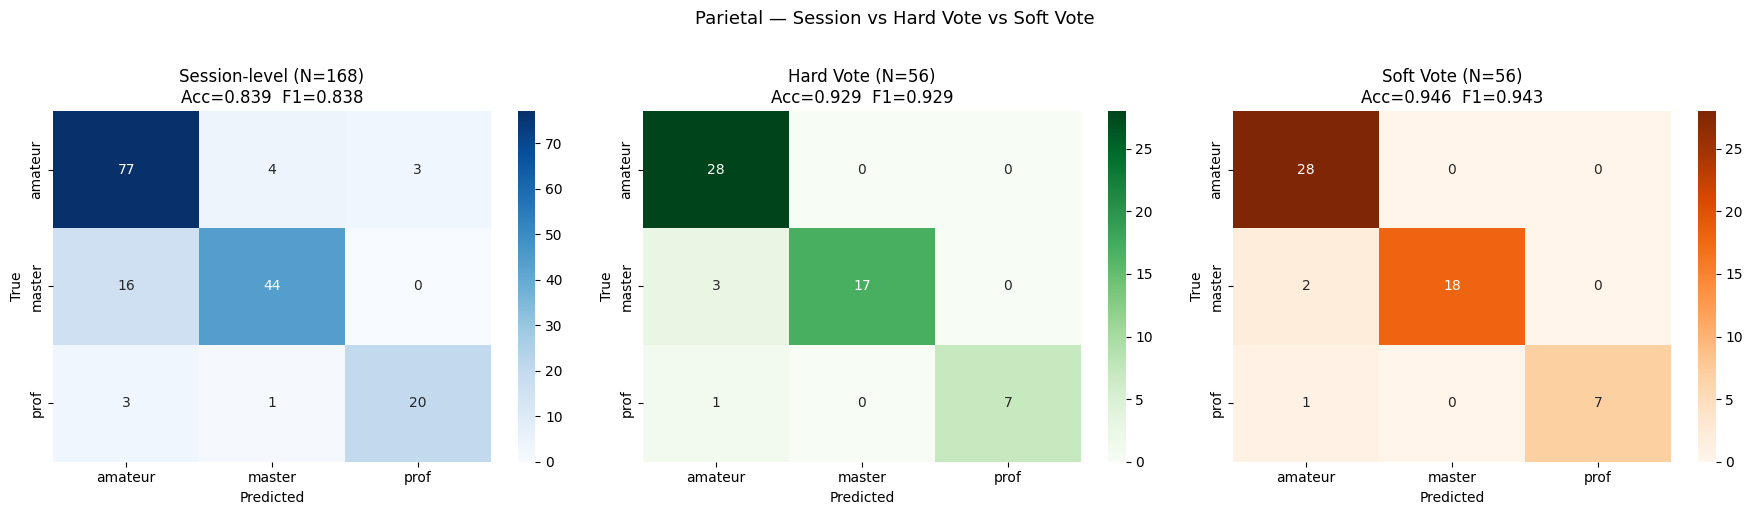

In [123]:
# ── Parietal 多數決分析：硬投票 vs 軟投票 ──
from scipy import stats

r = combined_results['Parietal']
preds_all = r['preds']
true_all  = r['true']
proba_all = r['proba']   # (168, 3)

print('=' * 105)
print('Parietal — Hard Vote vs Soft Vote (PLV→40 + BE→20)')
print('=' * 105)
print(f'{"Subject":<15s} {"True":>8s} {"ss01":>7s} {"ss02":>7s} {"ss03":>7s} '
      f'{"Hard":>7s} {"Soft":>7s} {"Soft Prob (am/ma/pr)":>25s} {"H":>3s} {"S":>3s}')
print('-' * 105)

hard_preds, soft_preds, vote_true = [], [], []

for i, sub_id in enumerate(subject_ids):
    true_label = subject_labels[sub_id]
    idx = slice(i*3, i*3+3)
    p1, p2, p3 = preds_all[i*3], preds_all[i*3+1], preds_all[i*3+2]

    # Hard vote: 多數決
    hard = int(stats.mode([p1, p2, p3], keepdims=False).mode)

    # Soft vote: 3 session 機率平均後取 argmax
    mean_proba = proba_all[idx].mean(axis=0)  # (3,)
    soft = int(np.argmax(mean_proba))

    hard_preds.append(hard)
    soft_preds.append(soft)
    vote_true.append(true_label)

    h_mark = 'O' if hard == true_label else 'X'
    s_mark = 'O' if soft == true_label else 'X'
    prob_str = f'[{mean_proba[0]:.2f} / {mean_proba[1]:.2f} / {mean_proba[2]:.2f}]'

    print(f'{sub_id:<15s} {CLASS_NAMES[true_label]:>8s} '
          f'{CLASS_NAMES[int(p1)]:>7s} {CLASS_NAMES[int(p2)]:>7s} {CLASS_NAMES[int(p3)]:>7s} '
          f'{CLASS_NAMES[hard]:>7s} {CLASS_NAMES[soft]:>7s} {prob_str:>25s} {h_mark:>3s} {s_mark:>3s}')

hard_preds = np.array(hard_preds)
soft_preds = np.array(soft_preds)
vote_true  = np.array(vote_true)

# Metrics
hard_acc = accuracy_score(vote_true, hard_preds)
hard_f1  = f1_score(vote_true, hard_preds, average='macro', zero_division=0)
soft_acc = accuracy_score(vote_true, soft_preds)
soft_f1  = f1_score(vote_true, soft_preds, average='macro', zero_division=0)

print('=' * 105)
print(f'\nSession-level:  Acc = {r["acc"]:.3f}   F1 = {r["f1"]:.3f}   (N = {len(preds_all)} samples)')
print(f'Hard Vote:      Acc = {hard_acc:.3f}   F1 = {hard_f1:.3f}   (N = {len(hard_preds)} subjects)')
print(f'Soft Vote:      Acc = {soft_acc:.3f}   F1 = {soft_f1:.3f}   (N = {len(soft_preds)} subjects)')

# 差異分析
diff_mask = hard_preds != soft_preds
n_diff = diff_mask.sum()
print(f'\n硬投票 vs 軟投票不一致: {n_diff} / {len(hard_preds)} subjects')
for i, sub_id in enumerate(subject_ids):
    if diff_mask[i]:
        true_g = CLASS_NAMES[vote_true[i]]
        hard_g = CLASS_NAMES[hard_preds[i]]
        soft_g = CLASS_NAMES[soft_preds[i]]
        h_ok = 'O' if hard_preds[i] == vote_true[i] else 'X'
        s_ok = 'O' if soft_preds[i] == vote_true[i] else 'X'
        print(f'  {sub_id:<15s} true={true_g:<8s} hard={hard_g}({h_ok})  soft={soft_g}({s_ok})')

# Classification Reports
for name, preds in [('Hard Vote', hard_preds), ('Soft Vote', soft_preds)]:
    print(f'\n{"="*60}')
    print(f'Parietal — {name} Classification Report')
    print(f'{"="*60}')
    print(classification_report(vote_true, preds,
                                target_names=CLASS_NAMES, zero_division=0))

# 混淆矩陣: Session / Hard / Soft
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_session = confusion_matrix(true_all, preds_all, labels=[0, 1, 2])
sns.heatmap(cm_session, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title(f'Session-level (N={len(preds_all)})\nAcc={r["acc"]:.3f}  F1={r["f1"]:.3f}')

cm_hard = confusion_matrix(vote_true, hard_preds, labels=[0, 1, 2])
sns.heatmap(cm_hard, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title(f'Hard Vote (N={len(hard_preds)})\nAcc={hard_acc:.3f}  F1={hard_f1:.3f}')

cm_soft = confusion_matrix(vote_true, soft_preds, labels=[0, 1, 2])
sns.heatmap(cm_soft, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[2])
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')
axes[2].set_title(f'Soft Vote (N={len(soft_preds)})\nAcc={soft_acc:.3f}  F1={soft_f1:.3f}')

plt.suptitle('Parietal — Session vs Hard Vote vs Soft Vote', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV_BE\svm_plv_be_parietal_majority_vote.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [124]:
# ── 多腦區組合實驗：Parietal + 其他區 vs Parietal 單區 vs ALL 32ch ──
import time

ALL_CH = sorted(set(sum(REGIONS.values(), [])))
combos = {
    'Parietal (baseline)':           REGIONS['Parietal'],
    'Parietal + Frontal':            REGIONS['Parietal'] + REGIONS['Frontal'],
    'Parietal + Central':            REGIONS['Parietal'] + REGIONS['Central'],
    'Parietal + Frontal + Central':  REGIONS['Parietal'] + REGIONS['Frontal'] + REGIONS['Central'],
    'ALL_32ch':                      ALL_CH,
}

print('=' * 95)
print(f'{"Combination":<32s} {"#ch":>4s} {"#dims":>6s} {"PCA":>5s} {"Acc":>7s} {"F1":>7s} {"vs Pari":>9s}')
print('-' * 95)

baseline_acc = None
combo_results = {}
for name, ch_idx in combos.items():
    t0 = time.time()
    acc, f1, per_sub, preds, true, proba, dims, pca_n, pca_plv_n, pca_be_n = run_loso_combined(
        X_plv, X_be, ch_idx, y_all, subject_split, subject_ids, subject_labels,
        pca_variance=0.95)
    if baseline_acc is None:
        baseline_acc = acc
        delta_str = '---'
    else:
        delta = acc - baseline_acc
        delta_str = f'{delta:+.3f}'
    combo_results[name] = {'acc': acc, 'f1': f1, 'preds': preds, 'true': true,
                           'proba': proba, 'ch_idx': ch_idx,
                           'pca_plv_n': pca_plv_n, 'pca_be_n': pca_be_n}
    print(f'{name:<32s} {len(ch_idx):4d} {dims:6d} {pca_n:5d} {acc:7.3f} {f1:7.3f} {delta_str:>9s}  '
          f'({time.time()-t0:.1f}s)')

print('=' * 95)

# Subject-level soft vote 也算一下
from sklearn.metrics import accuracy_score, f1_score
print()
print('Subject-level soft vote 比較:')
print(f'{"Combination":<32s} {"Vote Acc":>9s} {"Vote F1":>8s} {"vs Pari":>9s}')
print('-' * 70)
baseline_vote_acc = None
for name, r in combo_results.items():
    proba = r['proba']
    sub_proba = np.array([proba[i*3:i*3+3].mean(axis=0) for i in range(len(subject_ids))])
    sub_pred = np.argmax(sub_proba, axis=1)
    sub_true = np.array([subject_labels[s] for s in subject_ids])
    v_acc = accuracy_score(sub_true, sub_pred)
    v_f1 = f1_score(sub_true, sub_pred, average='macro', zero_division=0)
    if baseline_vote_acc is None:
        baseline_vote_acc = v_acc; delta = '---'
    else:
        delta = f'{v_acc - baseline_vote_acc:+.3f}'
    print(f'{name:<32s} {v_acc:9.3f} {v_f1:8.3f} {delta:>9s}')
print('-' * 70)
print('結論判讀:')
print('  - 任一組合 Acc > Parietal baseline → 加進去那區是有用的, 值得用組合')
print('  - 任一組合 Acc <= Parietal baseline → 加區只是稀釋訊號, Parietal 單區已最佳')
print('  - 通常 ALL 會掉最多, 因為加入了 Temporal/Occipital 兩個弱區當雜訊')

Combination                       #ch  #dims   PCA     Acc      F1   vs Pari
-----------------------------------------------------------------------------------------------
Parietal (baseline)                 9    225    28   0.839   0.838       ---  (1.9s)
Parietal + Frontal                 16    680    53   0.839   0.838    +0.000  (4.0s)
Parietal + Central                 16    680    47   0.756   0.764    -0.083  (4.0s)
Parietal + Frontal + Central       23   1380    66   0.792   0.795    -0.048  (5.4s)
ALL_32ch                           32   2640    73   0.821   0.816    -0.018  (6.7s)

Subject-level soft vote 比較:
Combination                       Vote Acc  Vote F1   vs Pari
----------------------------------------------------------------------
Parietal (baseline)                  0.946    0.943       ---
Parietal + Frontal                   0.929    0.913    -0.018
Parietal + Central                   0.893    0.883    -0.054
Parietal + Frontal + Central         0.893    0.883   

In [125]:
# ── Hybrid 實驗: BE 固定 Parietal, PLV 跑多區組合 ──
# 動機: RV coefficient 顯示 BE 跨腦區冗餘 (Frontal_BE vs Parietal_BE = 0.716)
#       但 PLV 跨腦區獨立 (Frontal_PLV vs Parietal_PLV = 0.136)
#       → BE 加更多區只是稀釋, PLV 加區可能帶來新資訊
import time
from sklearn.metrics import accuracy_score, f1_score

def run_loso_split(X_plv, X_be, ch_plv, ch_be, y_all, subject_split, subject_ids,
                   subject_labels, pca_variance=0.95):
    """跟 run_loso_combined 一樣的 pipeline, 但 PLV 跟 BE 用不同的 ch_idx"""
    feat_plv = extract_plv_features(X_plv, ch_plv)
    feat_be  = extract_be_features(X_be, ch_be)
    all_preds, all_true, all_proba = [], [], []
    pca_plv_dims, pca_be_dims = [], []

    for test_subject in subject_ids:
        m = subject_split == test_subject
        y_tr = y_all[~m].astype(int); y_te = y_all[m].astype(int)
        # PLV branch
        sc_p = StandardScaler(); plv_tr = sc_p.fit_transform(feat_plv[~m]); plv_te = sc_p.transform(feat_plv[m])
        pca_p = PCA(n_components=pca_variance); plv_tr = pca_p.fit_transform(plv_tr); plv_te = pca_p.transform(plv_te)
        pca_plv_dims.append(pca_p.n_components_)
        # BE branch
        sc_b = StandardScaler(); be_tr = sc_b.fit_transform(feat_be[~m]); be_te = sc_b.transform(feat_be[m])
        pca_b = PCA(n_components=pca_variance); be_tr = pca_b.fit_transform(be_tr); be_te = pca_b.transform(be_te)
        pca_be_dims.append(pca_b.n_components_)
        # concat + post-scale
        X_tr = np.hstack([plv_tr, be_tr]); X_te = np.hstack([plv_te, be_te])
        sc_f = StandardScaler(); X_tr = sc_f.fit_transform(X_tr); X_te = sc_f.transform(X_te)
        clf = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced',
                  random_state=42, probability=True)
        clf.fit(X_tr, y_tr)
        all_preds.extend(clf.predict(X_te))
        all_true.extend(y_te)
        all_proba.extend(clf.predict_proba(X_te))
    all_preds, all_true, all_proba = np.array(all_preds), np.array(all_true), np.array(all_proba)
    acc = accuracy_score(all_true, all_preds)
    f1  = f1_score(all_true, all_preds, average='macro', zero_division=0)
    return acc, f1, all_preds, all_true, all_proba, int(np.median(pca_plv_dims)), int(np.median(pca_be_dims))


ALL_CH = sorted(set(sum(REGIONS.values(), [])))
PARI = REGIONS['Parietal']

# BE 固定 Parietal, PLV 跑不同組合
plv_combos = {
    'PLV: Parietal':                      PARI,
    'PLV: Parietal + Frontal':            PARI + REGIONS['Frontal'],
    'PLV: Parietal + Central':            PARI + REGIONS['Central'],
    'PLV: Parietal + Frontal + Central':  PARI + REGIONS['Frontal'] + REGIONS['Central'],
    'PLV: ALL_32ch':                      ALL_CH,
}

print('=' * 105)
print(f'BE branch 固定 = Parietal (9ch),  PLV branch 變動')
print('=' * 105)
print(f'{"PLV configuration":<38s} {"PLV ch":>7s} {"PCA p":>6s} {"PCA b":>6s} {"Acc":>7s} {"F1":>7s} {"vs base":>9s}  {"time":>6s}')
print('-' * 105)

split_results = {}
baseline_acc = None
for name, ch_plv in plv_combos.items():
    t0 = time.time()
    acc, f1, preds, true, proba, pca_p, pca_b = run_loso_split(
        X_plv, X_be, ch_plv, PARI, y_all, subject_split, subject_ids, subject_labels)
    if baseline_acc is None:
        baseline_acc = acc; delta = '---'
    else:
        delta = f'{acc - baseline_acc:+.3f}'
    split_results[name] = {'acc': acc, 'f1': f1, 'proba': proba, 'preds': preds, 'true': true}
    print(f'{name:<38s} {len(ch_plv):7d} {pca_p:6d} {pca_b:6d} {acc:7.3f} {f1:7.3f} {delta:>9s}  {time.time()-t0:5.1f}s')

print('=' * 105)

# Subject-level soft vote
print()
print('Subject-level soft vote 比較:')
print(f'{"PLV configuration":<38s} {"Vote Acc":>9s} {"Vote F1":>8s} {"vs base":>9s}')
print('-' * 78)
baseline_vote = None
for name, r in split_results.items():
    proba = r['proba']
    sub_proba = np.array([proba[i*3:i*3+3].mean(axis=0) for i in range(len(subject_ids))])
    sub_pred = np.argmax(sub_proba, axis=1)
    sub_true = np.array([subject_labels[s] for s in subject_ids])
    v_acc = accuracy_score(sub_true, sub_pred)
    v_f1  = f1_score(sub_true, sub_pred, average='macro', zero_division=0)
    if baseline_vote is None:
        baseline_vote = v_acc; delta = '---'
    else:
        delta = f'{v_acc - baseline_vote:+.3f}'
    print(f'{name:<38s} {v_acc:9.3f} {v_f1:8.3f} {delta:>9s}')
print('-' * 78)
print()
print('讀表建議:')
print('  - 加 PLV 區後 Acc 上升 → 該區的 PLV 帶來新訊息, 印證 RV 預測 (PLV 跨區獨立)')
print('  - 加 PLV 區後 Acc 持平/下降 → PLV 訊號也集中在 Parietal, 加區只稀釋')
print('  - 跟前一個 cell (PLV+BE 同步加區) 比較, 看 hybrid 策略有沒有比 naive 加全部好')

BE branch 固定 = Parietal (9ch),  PLV branch 變動
PLV configuration                       PLV ch  PCA p  PCA b     Acc      F1   vs base    time
---------------------------------------------------------------------------------------------------------
PLV: Parietal                                9     21      7   0.839   0.838       ---    1.9s
PLV: Parietal + Frontal                     16     42      7   0.845   0.842    +0.006    3.5s
PLV: Parietal + Central                     16     37      7   0.774   0.781    -0.065    3.5s
PLV: Parietal + Frontal + Central           23     52      7   0.792   0.791    -0.048    4.5s
PLV: ALL_32ch                               32     57      7   0.798   0.799    -0.042    5.6s

Subject-level soft vote 比較:
PLV configuration                       Vote Acc  Vote F1   vs base
------------------------------------------------------------------------------
PLV: Parietal                              0.946    0.943       ---
PLV: Parietal + Frontal           